In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [8]:
df = pd.read_csv("covid_19_india.csv")

In [9]:
print("First 5 Rows of Dataset:\n")
print(df.head())

First 5 Rows of Dataset:

   Sno        Date     Time State/UnionTerritory ConfirmedIndianNational  \
0    1  2020-01-30  6:00 PM               Kerala                       1   
1    2  2020-01-31  6:00 PM               Kerala                       1   
2    3  2020-02-01  6:00 PM               Kerala                       2   
3    4  2020-02-02  6:00 PM               Kerala                       3   
4    5  2020-02-03  6:00 PM               Kerala                       3   

  ConfirmedForeignNational  Cured  Deaths  Confirmed  
0                        0      0       0          1  
1                        0      0       0          1  
2                        0      0       0          2  
3                        0      0       0          3  
4                        0      0       0          3  


In [10]:
print("\nDataset Information:\n")
print(df.info())




Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18110 entries, 0 to 18109
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Sno                       18110 non-null  int64 
 1   Date                      18110 non-null  object
 2   Time                      18110 non-null  object
 3   State/UnionTerritory      18110 non-null  object
 4   ConfirmedIndianNational   18110 non-null  object
 5   ConfirmedForeignNational  18110 non-null  object
 6   Cured                     18110 non-null  int64 
 7   Deaths                    18110 non-null  int64 
 8   Confirmed                 18110 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 1.2+ MB
None


In [11]:
print("\nMissing Values:\n")
print(df.isnull().sum())


Missing Values:

Sno                         0
Date                        0
Time                        0
State/UnionTerritory        0
ConfirmedIndianNational     0
ConfirmedForeignNational    0
Cured                       0
Deaths                      0
Confirmed                   0
dtype: int64


In [12]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=False)

In [13]:
df.dropna(inplace=True)

In [14]:
print("\nColumn Names:\n")
print(df.columns)


Column Names:

Index(['Sno', 'Date', 'Time', 'State/UnionTerritory',
       'ConfirmedIndianNational', 'ConfirmedForeignNational', 'Cured',
       'Deaths', 'Confirmed'],
      dtype='object')


In [15]:
print("\nSummary Statistics:\n")
print(df.describe())


Summary Statistics:

                Sno                           Date         Cured  \
count  18110.000000                          18110  1.811000e+04   
mean    9055.500000  2020-11-30 21:49:50.127001344  2.786375e+05   
min        1.000000            2020-01-30 00:00:00  0.000000e+00   
25%     4528.250000            2020-07-26 00:00:00  3.360250e+03   
50%     9055.500000            2020-12-03 00:00:00  3.336400e+04   
75%    13582.750000            2021-04-08 00:00:00  2.788698e+05   
max    18110.000000            2021-08-11 00:00:00  6.159676e+06   
std     5228.051023                            NaN  6.148909e+05   

              Deaths     Confirmed  
count   18110.000000  1.811000e+04  
mean     4052.402264  3.010314e+05  
min         0.000000  0.000000e+00  
25%        32.000000  4.376750e+03  
50%       588.000000  3.977350e+04  
75%      3643.750000  3.001498e+05  
max    134201.000000  6.363442e+06  
std     10919.076411  6.561489e+05  


In [16]:
total_confirmed = df['Confirmed'].sum()
total_cured = df['Cured'].sum()
total_deaths = df['Deaths'].sum()

print("\nTotal Confirmed Cases:", total_confirmed)
print("Total Cured Cases:", total_cured)
print("Total Death Cases:", total_deaths)


Total Confirmed Cases: 5451678687
Total Cured Cases: 5046125452
Total Death Cases: 73389005


In [17]:
state_cases = df.groupby('State/UnionTerritory')['Confirmed'].sum().sort_values(ascending=False)

print("\nTop 10 States with Highest Confirmed Cases:\n")
print(state_cases.head(10))




Top 10 States with Highest Confirmed Cases:

State/UnionTerritory
Maharashtra       1121491467
Karnataka          485970693
Kerala             458906023
Tamil Nadu         431928644
Andhra Pradesh     392432753
Uttar Pradesh      312625843
Delhi              287227765
West Bengal        263107876
Chhattisgarh       163776262
Rajasthan          162369656
Name: Confirmed, dtype: int64


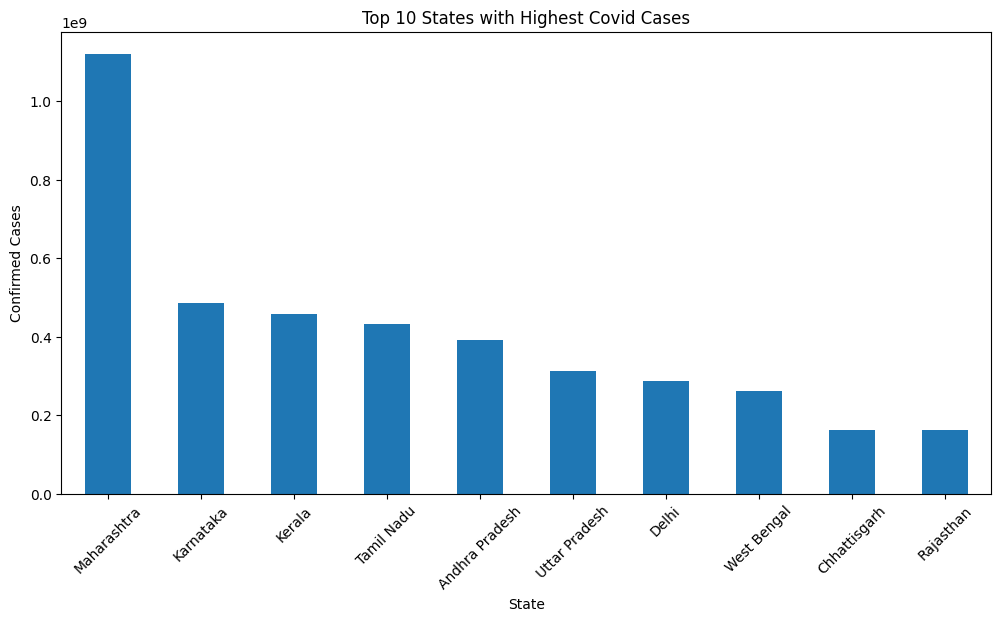

In [18]:
plt.figure(figsize=(12,6))
state_cases.head(10).plot(kind='bar')
plt.title("Top 10 States with Highest Covid Cases")
plt.xlabel("State")
plt.ylabel("Confirmed Cases")
plt.xticks(rotation=45)
plt.show()



In [19]:
daily_cases = df.groupby('Date')['Confirmed'].sum()

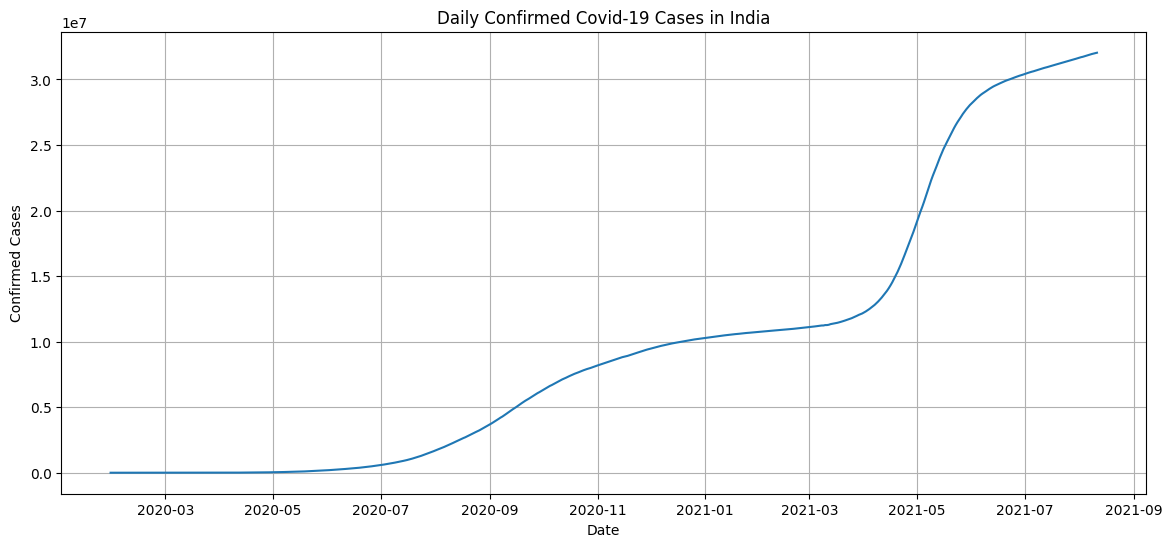

In [20]:
plt.figure(figsize=(14,6))
plt.plot(daily_cases.index, daily_cases.values)
plt.title("Daily Confirmed Covid-19 Cases in India")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.grid(True)
plt.show()



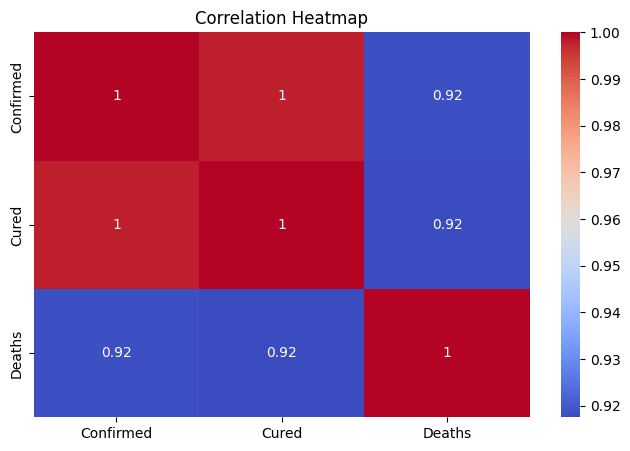

In [21]:
plt.figure(figsize=(8,5))
sns.heatmap(df[['Confirmed', 'Cured', 'Deaths']].corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [22]:
df['Active Cases'] = df['Confirmed'] - df['Cured'] - df['Deaths']



In [23]:
active_cases = df.groupby('State/UnionTerritory')['Active Cases'].sum().sort_values(ascending=False)



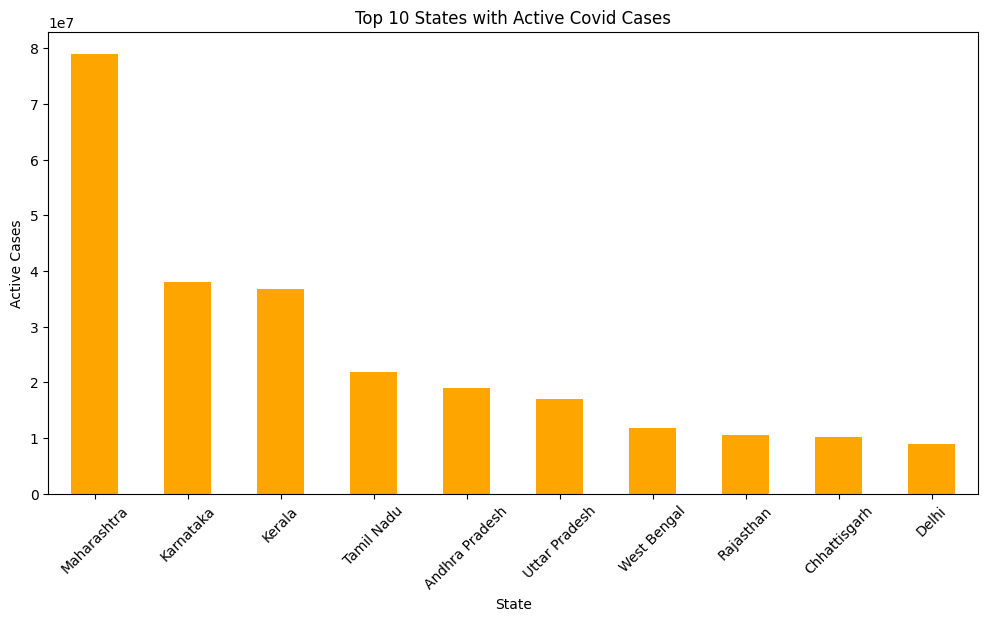

In [24]:
plt.figure(figsize=(12,6))
active_cases.head(10).plot(kind='bar', color='orange')
plt.title("Top 10 States with Active Covid Cases")
plt.xlabel("State")
plt.ylabel("Active Cases")
plt.xticks(rotation=45)
plt.show()

In [25]:
df.to_csv("cleaned_covid_data.csv", index=False)

print("\nCovid-19 Data Analysis Completed Successfully!")


Covid-19 Data Analysis Completed Successfully!
